In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('Fraud_Analysis_Dataset.csv')
df.head(5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1
1,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1
2,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1
3,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1
4,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1


In [3]:
#EDA
df.shape

(11142, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11142 entries, 0 to 11141
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            11142 non-null  int64  
 1   type            11142 non-null  object 
 2   amount          11142 non-null  float64
 3   nameOrig        11142 non-null  object 
 4   oldbalanceOrg   11142 non-null  float64
 5   newbalanceOrig  11142 non-null  float64
 6   nameDest        11142 non-null  object 
 7   oldbalanceDest  11142 non-null  float64
 8   newbalanceDest  11142 non-null  float64
 9   isFraud         11142 non-null  int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 870.6+ KB


In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

In [6]:
pd.set_option('display.float_format','{:.2f}'.format)

In [7]:
#statistics
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,11142.00,11142.00,11142.00,11142.00,11142.00,11142.00,11142.00
mean,8.72,213191.49,924117.26,824957.65,888354.08,1103211.48,0.10
std,16.07,760065.01,2143004.31,2089894.17,2601375.85,2982447.12,0.30
min,1.00,2.39,0.00,0.00,0.00,0.00,0.00
25%,2.00,4946.62,427.00,0.00,0.00,0.00,0.00
50%,6.00,16761.26,28169.50,4420.60,0.00,0.00,0.00
75%,7.00,154336.58,304085.48,111412.64,271155.47,318637.36,0.00
max,95.00,10000000.00,19900000.00,13000000.00,33000000.00,34600000.00,1.00


In [8]:
df["isFraud"].value_counts(normalize=True) * 100

isFraud
0   89.75
1   10.25
Name: proportion, dtype: float64

<Axes: xlabel='type', ylabel='count'>

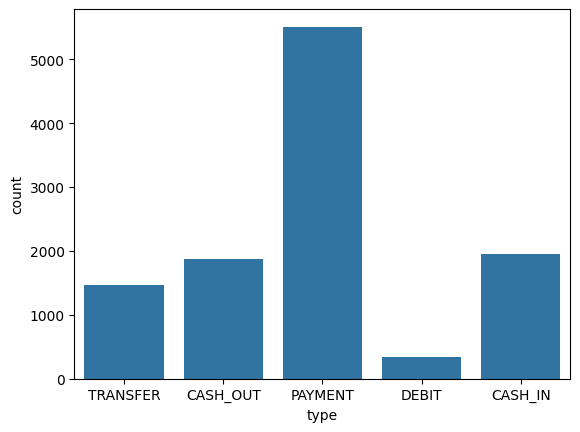

In [9]:
import seaborn as sns
sns.countplot(x='type',data=df)

<Axes: ylabel='amount'>

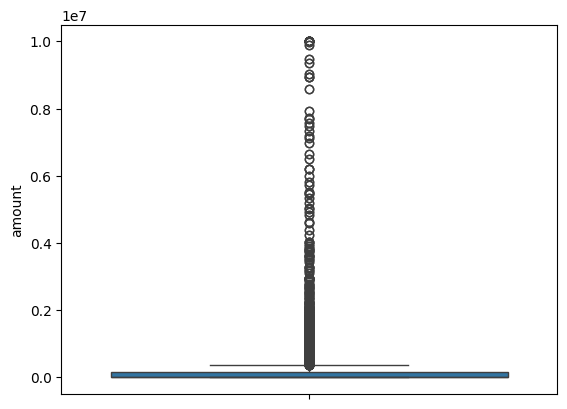

In [10]:
sns.boxplot(y=df['amount'])

In [11]:
df=df.drop(['nameOrig','nameDest','step'],axis=1)
df.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
0,TRANSFER,181.00,181.00,0.00,0.00,0.00,1
1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1
2,TRANSFER,2806.00,2806.00,0.00,0.00,0.00,1
3,CASH_OUT,2806.00,2806.00,0.00,26202.00,0.00,1
4,TRANSFER,20128.00,20128.00,0.00,0.00,0.00,1


In [12]:
df=pd.get_dummies(df,drop_first=True,dtype='int')
df

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,181.00,0.00,0.00,0.00,1,0,0,0,1
1,181.00,181.00,0.00,21182.00,0.00,1,1,0,0,0
2,2806.00,2806.00,0.00,0.00,0.00,1,0,0,0,1
3,2806.00,2806.00,0.00,26202.00,0.00,1,1,0,0,0
4,20128.00,20128.00,0.00,0.00,0.00,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
11137,6393.71,433084.38,426690.68,478421.00,210535.25,0,0,1,0,0
11138,298799.54,426690.68,127891.14,704355.36,5270364.19,0,1,0,0,0
11139,423159.63,127891.14,0.00,610479.00,749621.53,0,1,0,0,0
11140,1094.03,13918.00,12823.97,0.00,0.00,0,0,0,1,0


In [13]:
x=df.drop('isFraud',axis=1)
y=df.isFraud

In [15]:
x

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,181.00,181.00,0.00,0.00,0.00,0,0,0,1
1,181.00,181.00,0.00,21182.00,0.00,1,0,0,0
2,2806.00,2806.00,0.00,0.00,0.00,0,0,0,1
3,2806.00,2806.00,0.00,26202.00,0.00,1,0,0,0
4,20128.00,20128.00,0.00,0.00,0.00,0,0,0,1
...,...,...,...,...,...,...,...,...,...
11137,6393.71,433084.38,426690.68,478421.00,210535.25,0,1,0,0
11138,298799.54,426690.68,127891.14,704355.36,5270364.19,1,0,0,0
11139,423159.63,127891.14,0.00,610479.00,749621.53,1,0,0,0
11140,1094.03,13918.00,12823.97,0.00,0.00,0,0,1,0


In [16]:
y

0        1
1        1
2        1
3        1
4        1
        ..
11137    0
11138    0
11139    0
11140    0
11141    0
Name: isFraud, Length: 11142, dtype: int64

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [15]:
x_scale=scaler.fit_transform(x)
x_scale

array([[-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       [-0.28026556, -0.43115999, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27681175, -0.42993502, -0.39475428, ..., -0.17902209,
        -0.98910974,  2.57111955],
       ...,
       [ 0.27626264, -0.37156334, -0.39475428, ..., -0.17902209,
        -0.98910974, -0.38893563],
       [-0.27906425, -0.42474954, -0.38861782, ..., -0.17902209,
         1.01101017, -0.38893563],
       [-0.26835212, -0.4125955 , -0.38005076, ..., -0.17902209,
         1.01101017, -0.38893563]], shape=(11142, 9))

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_scale,y,random_state=70,test_size=0.3)

In [17]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred_tr=rf.predict(x_train)
y_pred_tt=rf.predict(x_test)

In [20]:

from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,precision_recall_curve
acc_tr=accuracy_score(y_train,y_pred_tr)
print('train',acc_tr)
acc_tt=accuracy_score(y_test,y_pred_tt)
print('test',acc_tt)

train 1.0
test 0.9943164822016153


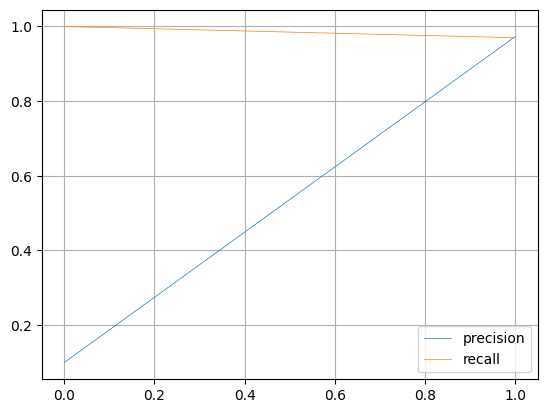

In [26]:
import matplotlib.pyplot as plt
precision,recall,threshold=precision_recall_curve(y_test,y_pred_tt)
plt.plot(threshold,precision[:-1],label='precision',linewidth=0.5)
plt.plot(threshold,recall[:-1],label='recall',linewidth=0.5)
plt.grid(True)
plt.legend()
plt.show()

In [27]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-6)  # avoid division by zero

# Find the threshold that gives the best F1 score
best_threshold = threshold[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print("✅ Best Threshold:", round(best_threshold, 2))
print("🏆 Best F1 Score:", round(best_f1, 3))

# Apply the optimal threshold to make predictions
y_pred_optimal = (y_pred_tt >= best_threshold).astype(int)

✅ Best Threshold: 1
🏆 Best F1 Score: 0.971


In [31]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [24]:
grid_params={
    'n_estimators':[1,2,4,5,6,10],
    'max_depth':[2,3,4,5,6,None],
    'min_samples_split':[10,50,40,80,100,150],
    'min_samples_leaf':[50,60,80,100,150,300]
}
grid=GridSearchCV(RandomForestClassifier(),grid_params,cv=5)
grid.fit(x_train,y_train)
print(grid.best_params_)

{'max_depth': None, 'min_samples_leaf': 50, 'min_samples_split': 10, 'n_estimators': 10}


In [32]:
from scipy.stats import randint
param_dist={
    'n_estimators':randint(1,10),
    'max_depth':[None,2,3,4,5,9,10],
    'min_samples_split':randint(2,100),
    'min_samples_leaf':randint(1,10)
}
ran_search=RandomizedSearchCV(RandomForestClassifier(),param_dist,cv=5,random_state=42)
ran_search.fit(x_train,y_train)
print(ran_search.best_params_)

{'max_depth': 9, 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 8}


In [53]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(class_weight="balanced",max_depth=9,min_samples_leaf=5,min_samples_split=3,n_estimators=8,oob_score=True)
rf.fit(x_train,y_train)

C:\Users\Daniel\Anaconda\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,8
,criterion,'gini'
,max_depth,9
,min_samples_split,3
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


In [54]:
#feature importance
importance=rf.feature_importances_
feature_importance=pd.Series(importance,index=x.columns).sort_values(ascending=True)
sorted_importance = feature_importance.sort_values(ascending=False)

print("Feature Importance:")
print(sorted_importance)


Feature Importance:
newbalanceOrig   0.33
oldbalanceOrg    0.24
type_PAYMENT     0.19
type_CASH_OUT    0.09
type_TRANSFER    0.04
amount           0.04
newbalanceDest   0.04
oldbalanceDest   0.03
type_DEBIT       0.00
dtype: float64


In [72]:
#Permutation importance
from sklearn.inspection import permutation_importance
results=permutation_importance(rf,x_train,y_train,random_state=42,n_repeats=10)
importance_df = pd.DataFrame({
 'feature': x.columns,   # column names
    'importance_mean': results.importances_mean,
    'importance_std': results.importances_std
}).sort_values(by="importance_mean", ascending=False)

print(importance_df)
print("="*7)
print(results.importances_mean)

          feature  importance_mean  importance_std
2  newbalanceOrig             0.10            0.00
1   oldbalanceOrg             0.10            0.00
3  oldbalanceDest             0.06            0.00
7    type_PAYMENT             0.05            0.00
0          amount             0.02            0.00
5   type_CASH_OUT             0.01            0.00
4  newbalanceDest             0.01            0.00
8   type_TRANSFER             0.00            0.00
6      type_DEBIT            -0.00            0.00
[ 0.02016925  0.0952558   0.09602513  0.06461085  0.00542377  0.01459161
 -0.00012822  0.04873702  0.00388511]


In [56]:
import shap
explainer=shap.TreeExplainer(rf)
shap_val=explainer.shap_values(x_train)
shap.summary_plot(shap_val,x_train)

ModuleNotFoundError: No module named 'numba'

In [57]:
print(rf.oob_score_)

0.9794845493011924


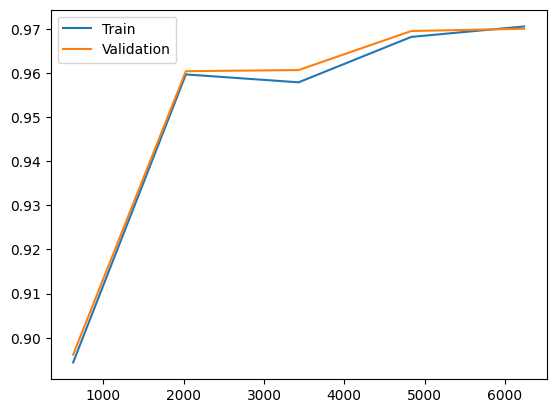

In [59]:
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
#train_size,train_scores,test_scores=leanrning_curve(RandomForestClassifier(random_state=42),x_train,y_train,cv=5,train_sizesnp.linespace(0.1,1.0,5))
train_size, train_scores, test_scores = learning_curve(
    RandomForestClassifier(max_depth=4,min_samples_leaf=100,min_samples_split=10,n_estimators=8,random_state=42), x_train, y_train, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 5)
)
plt.plot(train_size, train_scores.mean(axis=1), label="Train")
plt.plot(train_size, test_scores.mean(axis=1), label="Validation")
plt.legend()
plt.show()

In [61]:
from imblearn.over_sampling import SMOTE

In [62]:
smote=SMOTE(random_state=80)
x_train_sm,y_train_sm=smote.fit_resample(x_train,y_train)

In [63]:
y_pred_tr=rf.predict(x_train)
y_pred_tt=rf.predict(x_test)

In [64]:
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,roc_curve
acc_tr=accuracy_score(y_train,y_pred_tr)
print('train',acc_tr)
acc_tt=accuracy_score(y_test,y_pred_tt)
print('test',acc_tt)

train 0.9883318374150533
test 0.9778641938378702


In [21]:
y_pred_tr_=rf.predict_proba(x_train)[:,1]
y_pred_tt_=rf.predict_proba(x_test)[:,1]

In [66]:
auc_tr=roc_auc_score(y_train,y_pred_tr_)
aud_tt=roc_auc_score(y_test,y_pred_tt_)
print('train',auc_tr)
print('test',aud_tt)

train 0.9997054454177553
test 0.9961936753990389


In [67]:
fpr_tr, tpr_tr, _ = roc_curve(y_train, y_pred_tr_)
fpr_tt, tpr_tt, _ = roc_curve(y_test, y_pred_tt_)
print(f'fpr_train={fpr_tr} tpr_tr={tpr_tr}')
print(f'fpr_test={fpr_tt} tpr_test={tpr_tt}')

fpr_train=[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.43081986e-04
 1.43081986e-04 1.43081986e-04 1.43081986e-04 1.43081986e-04
 1.43081986e-04 1.43081986e-04 1.43081986e-04 1.43081986e-04
 1.43081986e-04 1.43081986e-04 1.43081986e-04 1.43081986e-04
 1.43081986e-04 1.43081986e-04 1.43081986e-04 1.43081986e-04
 1.43081986e-0

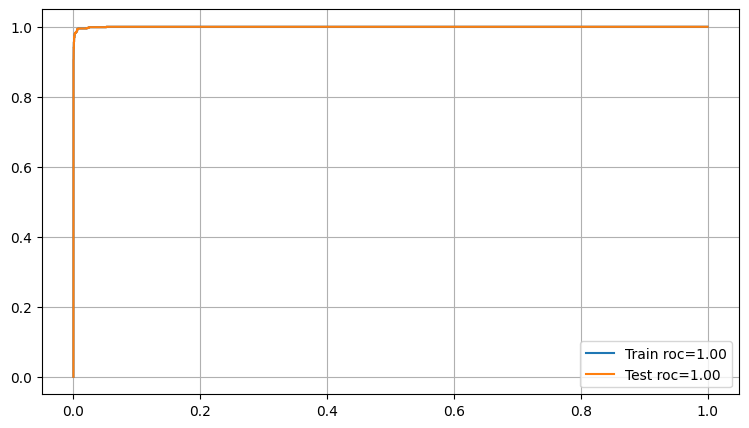

In [68]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
plt.plot(fpr_tr,tpr_tr,label=f'Train roc={auc_tr:.2f}')
plt.plot(fpr_tr,tpr_tr,label=f'Test roc={aud_tt:.2f}')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

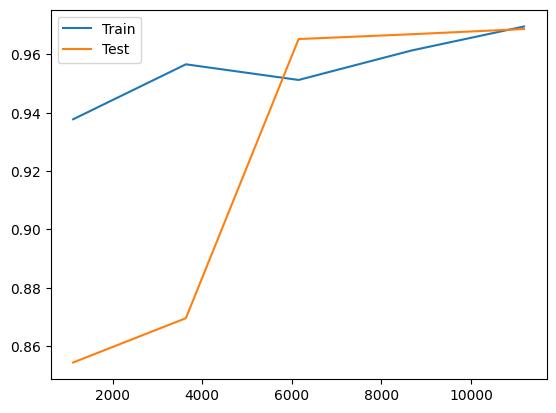

In [69]:
from sklearn.model_selection import learning_curve
train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(class_weight='balanced',max_depth=4,min_samples_leaf=150,min_samples_split=15,n_estimators=8,random_state=42), x_train_sm, y_train_sm, cv=5, train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train")
plt.plot(train_sizes, test_scores.mean(axis=1), label="Test")
plt.legend()
plt.show()

In [58]:
from sklearn.metrics import confusion_matrix
con=confusion_matrix(y_train,y_pred_tr)
print('trin',con)
con_tt=confusion_matrix(y_test,y_pred_tt)
print('test',con_tt)

trin [[6980    9]
 [  28  782]]
test [[2995   16]
 [  19  313]]


<Axes: >

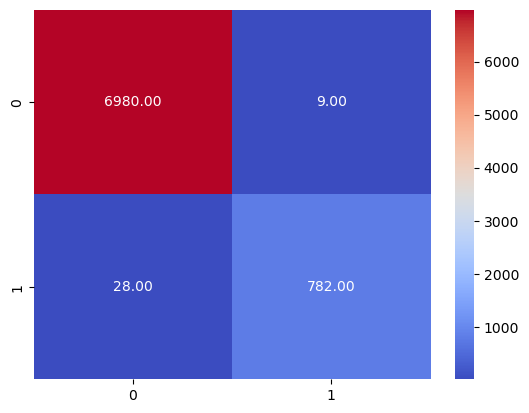

In [60]:
sns.heatmap(con,annot=True,cmap='coolwarm',fmt='.2f')

In [78]:
print(x_train.shape[1])

9


In [36]:
from sklearn.linear_model import LogisticRegression
lgr=LogisticRegression()

In [38]:
lgr.fit(x_train,y_train)

LogisticRegression()

In [40]:
y_pred=lgr.predict(x_test)
y_pred

array([0, 1, 0, ..., 0, 0, 0], dtype=int64)

In [41]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
accuracy=accuracy_score(y_pred,y_test)
accuracy

0.9566257852228537

In [42]:
confusion=confusion_matrix(y_pred,y_test)
confusion

array([[3007,  141],
       [   4,  191]], dtype=int64)

In [43]:
print(lgr.intercept_)

[-6.03003579]


In [44]:
print(lgr.coef_)

[[-0.60872228  9.92756843 -9.93398625  0.43352363 -1.1141155   1.94866379
  -0.4692458  -1.2754612   1.84465494]]


In [45]:
clf=classification_report(y_pred,y_test)
clf

'              precision    recall  f1-score   support\n\n           0       1.00      0.96      0.98      3148\n           1       0.58      0.98      0.72       195\n\n    accuracy                           0.96      3343\n   macro avg       0.79      0.97      0.85      3343\nweighted avg       0.97      0.96      0.96      3343\n'

In [49]:
print(clf)

              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3148
           1       0.58      0.98      0.72       195

    accuracy                           0.96      3343
   macro avg       0.79      0.97      0.85      3343
weighted avg       0.97      0.96      0.96      3343



In [50]:
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(   n_estimators=300,
    max_depth=None,          # restrict depth
    min_samples_split=5,   # avoid splitting too aggressively
    min_samples_leaf=3,    # each leaf needs more samples
    max_features="sqrt",   # fewer features at each split
    random_state=42)
et.fit(x_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,False
,oob_score,False


In [51]:
y_pred_et = et.predict(x_test)
y_pred_ettr = et.predict(x_train)
# Compare accuracy
print("Random Forest Accuracy test randomforest:", accuracy_score(y_test, y_pred_tt))
print("Extra Trees Accuracy test extra tree:", accuracy_score(y_test, y_pred_et))
print("Random Forest Accuracy train_random forest:", accuracy_score(y_train, y_pred_tr))
print("Extra Trees Accuracy train_extra tree:", accuracy_score(y_train, y_pred_ettr))

Random Forest Accuracy test randomforest: 0.9940173496859108
Extra Trees Accuracy test extra tree: 0.9799581214478014
Random Forest Accuracy train_random forest: 1.0
Extra Trees Accuracy train_extra tree: 0.976791896396974


In [52]:
from sklearn.model_selection import cross_val_score
import numpy as np

scores = cross_val_score(et, x_train, y_train, cv=5)
print("CV Mean:", np.mean(scores), "CV Std:", np.std(scores))

CV Mean: 0.9760224338415486 CV Std: 0.003816989340172914
